**===========|| PROJETO EDA - AVALIAÇÃO DE RISCO DE CRÉDITO ||===========**

In [2]:
### DEFINIÇÃO DAS PERGUNTAS DE NEGÓCIOS:

# 1) Clientes com maior renda anual apresentam menores taxas de inadiplência?
# 2) O tipo de moradia ou o estado civil têm relação direta com o risco de atraso de pagamento?
# 3) A quantidade de filhos possui relação com as txas de inadimplência?

In [3]:
# IMPORT DAS BIBLIOTECAS / CONFIGURAÇÃOES PRÉVIAS / LEITURA DA BASE 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 130)

df_clientes = pd.read_csv('../dados/application_record.csv')
df_credito = pd.read_csv('../dados/credit_record.csv')

print("SHAPE | df_clientes:", df_clientes.shape)
print("SHAPE | df_credito:", df_credito.shape)

SHAPE | df_clientes: (438557, 18)
SHAPE | df_credito: (1048575, 3)


In [4]:
# EXIBIÇÃO DAS INFORMAÇÕES GERAIS 

display(df_clientes.info(memory_usage='deep'))
display(df_credito.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 66.0 MB


None

In [5]:
# RENOMEAÇÃO DAS COLUNAS EM DF_CLIENTES E DF_CREDITO

novos_nomes = {
    'ID': 'id_cliente',
    'CODE_GENDER': 'genero',
    'FLAG_OWN_CAR': 'possui_carro',
    'FLAG_OWN_REALTY': 'possui_imovel',
    'CNT_CHILDREN': 'qtd_filhos',
    'AMT_INCOME_TOTAL': 'renda_anual',
    'NAME_INCOME_TYPE': 'tipo_renda',
    'NAME_EDUCATION_TYPE': 'escolaridade',
    'NAME_FAMILY_STATUS': 'estado_civil',
    'NAME_HOUSING_TYPE': 'tipo_moradia',
    'DAYS_BIRTH': 'dias_nascimento',
    'DAYS_EMPLOYED': 'dias_empregado',
    'FLAG_MOBIL': 'possui_celular',
    'FLAG_WORK_PHONE': 'possui_tel_trabalho',
    'FLAG_PHONE': 'possui_tel_fixo',
    'FLAG_EMAIL': 'possui_email',
    'OCCUPATION_TYPE': 'ocupacao',
    'CNT_FAM_MEMBERS': 'qtd_membros_familia'
}

df_clientes = df_clientes.rename(columns=novos_nomes)

df_credito = df_credito.rename(columns={
    'ID': 'id_cliente',
    'MONTHS_BALANCE': 'mes_referencia',
    'STATUS': 'status_pagamento'
})

In [6]:
# EXIBIÇÃO DAS INFORMAÇÕES GERAIS COM COLUNAS RENOMEADAS

display(df_clientes.info(memory_usage='deep'))
display(df_credito.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_cliente           438557 non-null  int64  
 1   genero               438557 non-null  object 
 2   possui_carro         438557 non-null  object 
 3   possui_imovel        438557 non-null  object 
 4   qtd_filhos           438557 non-null  int64  
 5   renda_anual          438557 non-null  float64
 6   tipo_renda           438557 non-null  object 
 7   escolaridade         438557 non-null  object 
 8   estado_civil         438557 non-null  object 
 9   tipo_moradia         438557 non-null  object 
 10  dias_nascimento      438557 non-null  int64  
 11  dias_empregado       438557 non-null  int64  
 12  possui_celular       438557 non-null  int64  
 13  possui_tel_trabalho  438557 non-null  int64  
 14  possui_tel_fixo      438557 non-null  int64  
 15  possui_email     

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   id_cliente        1048575 non-null  int64 
 1   mes_referencia    1048575 non-null  int64 
 2   status_pagamento  1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 66.0 MB


None

In [7]:
# INSPEÇÃO DE NaN POR COLUNAS

nulos_clientes = pd.DataFrame({
    'nulos_clientes': df_clientes.isna().sum(),
    'pct': (df_clientes.isna().mean() * 100).round(2)
})
nulos_clientes = nulos_clientes[nulos_clientes['nulos_clientes'] > 0].sort_values('nulos_clientes', ascending=False)
display(nulos_clientes)

nulos_credito = pd.DataFrame({
    'nulos_credito': df_credito.isna().sum(),
    'pct': (df_credito.isna().mean() * 100).round(2)
})
nulos_credito = nulos_credito[nulos_credito['nulos_credito'] > 0].sort_values('nulos_credito', ascending=False)
display(nulos_credito)

,nulos_clientes,pct
ocupacao,134203,30.6


,nulos_credito,pct


In [8]:
# INSPREÇÃO DE NaN POR LINHAS

print("linhas com algum NaN --- base clientes --- base crédito:",  df_clientes.isna().any(axis=1).sum())
print("linhas completas --- base clientes:",  df_clientes.notna().all(axis=1).sum())

print("linhas com algum NaN --- base crédito:",  df_credito.isna().any(axis=1).sum())
print("linhas completas --- base crédito:",  df_credito.notna().all(axis=1).sum())

linhas com algum NaN --- base clientes --- base crédito: 134203
linhas completas --- base clientes: 304354
linhas com algum NaN --- base crédito: 0
linhas completas --- base crédito: 1048575


In [9]:
df_clientes['ocupacao'].unique()

array([nan, 'Security staff', 'Sales staff', 'Accountants', 'Laborers',
       'Managers', 'Drivers', 'Core staff', 'High skill tech staff',
       'Cleaning staff', 'Private service staff', 'Cooking staff',
       'Low-skill Laborers', 'Medicine staff', 'Secretaries',
       'Waiters/barmen staff', 'HR staff', 'Realty agents', 'IT staff'],
      dtype=object)

In [10]:
# RENOMEAÇÃO DAS OCORRÊNCIAS EM OCUPAÇÃO

mapa_ocupacao = {
    'Security staff': 'Equipe de Segurança',
    'Sales staff': 'Vendas',
    'Accountants': 'Contadores',
    'Laborers': 'Operários',
    'Managers': 'Gerentes',
    'Drivers': 'Motoristas',
    'Core staff': 'Equipe Principal',
    'High skill tech staff': 'Equipe Técnica Especializada',
    'Cleaning staff': 'Equipe de Limpeza',
    'Private service staff': 'Serviços Privados',
    'Cooking staff': 'Cozinha',
    'Low-skill Laborers': 'Trabalhadores Operacionais',
    'Medicine staff': 'Equipe de Saúde',
    'Secretaries': 'Secretários(as)',
    'Waiters/barmen staff': 'Garçons/Bartenders',
    'HR staff': 'Recursos Humanos',
    'Realty agents': 'Corretores de Imóveis',
    'IT staff': 'Equipe de TI'
}

df_clientes['ocupacao'] = df_clientes['ocupacao'].replace(mapa_ocupacao)

In [11]:
df_clientes['tipo_renda'].unique()

array(['Working', 'Commercial associate', 'Pensioner', 'State servant',
       'Student'], dtype=object)

In [12]:
# RENOMEAÇÃO DAS OCORRÊNCIAS EM TIPO_RENDA

mapa_tipo_renda = {
    'Working': 'Empregado',
    'Commercial associate': 'Autônomo / Comercial',
    'Pensioner': 'Aposentado / Pensionista',
    'State servant': 'Servidor Público',
    'Student': 'Estudante'
}

df_clientes['tipo_renda'] = df_clientes['tipo_renda'].replace(mapa_tipo_renda)

In [13]:
df_clientes['estado_civil'].unique()

array(['Civil marriage', 'Married', 'Single / not married', 'Separated',
       'Widow'], dtype=object)

In [14]:
# RENOMEAÇÃO DAS OCORRÊNCIAS EM ESTADO_CIVIL

mapa_estado_civil = {
    'Married': 'Casado(a)',
    'Single / not married': 'Solteiro(a)',
    'Civil marriage': 'União Estável',
    'Separated': 'Separado(a)',
    'Widow': 'Viúvo(a)'
}

df_clientes['estado_civil'] = df_clientes['estado_civil'].replace(mapa_estado_civil)
print(df_clientes['estado_civil'].unique())

['União Estável' 'Casado(a)' 'Solteiro(a)' 'Separado(a)' 'Viúvo(a)']


In [15]:
df_clientes['tipo_moradia'].unique()

array(['Rented apartment', 'House / apartment', 'Municipal apartment',
       'With parents', 'Co-op apartment', 'Office apartment'],
      dtype=object)

In [16]:
# RENOMEAÇÃO DAS OCORRÊNCIAS EM TIPO_MORADIA

mapa_tipo_moradia = {
    'House / apartment': 'Casa / Apartamento Próprio',
    'With parents': 'Com os Pais',
    'Municipal apartment': 'Habitação Pública',
    'Rented apartment': 'Aluguel',
    'Office apartment': 'Alojamento da Empresa',
    'Co-op apartment': 'Cooperativa Habitacional'
}

df_clientes['tipo_moradia'] = df_clientes['tipo_moradia'].replace(mapa_tipo_moradia)
print(df_clientes['tipo_moradia'].unique())

['Aluguel' 'Casa / Apartamento Próprio' 'Habitação Pública' 'Com os Pais'
 'Cooperativa Habitacional' 'Alojamento da Empresa']


In [17]:
df_clientes['escolaridade'].unique()

array(['Higher education', 'Secondary / secondary special',
       'Incomplete higher', 'Lower secondary', 'Academic degree'],
      dtype=object)

In [18]:
# RENOMEAÇÃO DAS OCORRÊNCIAS EM ESCOLARIDADE

mapa_escolaridade = {
    'Secondary / secondary special': 'Ensino Médio / Técnico',
    'Higher education': 'Ensino Superior',
    'Incomplete higher': 'Superior Incompleto',
    'Lower secondary': 'Ensino Fundamental',
    'Academic degree': 'Pós-Graduação',
}

# Supondo que a coluna se chame 'escolaridade' (ou 'education_type')
df_clientes['escolaridade'] = df_clientes['escolaridade'].replace(
    mapa_escolaridade
)

# Validação dos valores únicos após a alteração
print(df_clientes['escolaridade'].unique())

['Ensino Superior' 'Ensino Médio / Técnico' 'Superior Incompleto'
 'Ensino Fundamental' 'Pós-Graduação']


In [19]:
#FAZENDO DESCRIBE DO df_clientes PARA VERIFICAR AS ESTATÍSTICAS DESCRITIVAS

df_clientes.describe().round(2)


,id_cliente,qtd_filhos,renda_anual,dias_nascimento,dias_empregado,possui_celular,possui_tel_trabalho,possui_tel_fixo,possui_email,qtd_membros_familia
count,438557.00,438557.00,438557.00,438557.00,438557.00,438557.0,438557.00,438557.00,438557.00,438557.00
mean,6022176.27,0.43,187524.29,-15997.90,60563.68,1.0,0.21,0.29,0.11,2.19
std,571637.02,0.72,110086.85,4185.03,138767.80,0.0,0.40,0.45,0.31,0.90
min,5008804.00,0.00,26100.00,-25201.00,-17531.00,1.0,0.00,0.00,0.00,1.00
25%,5609375.00,0.00,121500.00,-19483.00,-3103.00,1.0,0.00,0.00,0.00,2.00
50%,6047745.00,0.00,160780.50,-15630.00,-1467.00,1.0,0.00,0.00,0.00,2.00
75%,6456971.00,1.00,225000.00,-12514.00,-371.00,1.0,0.00,1.00,0.00,3.00
max,7999952.00,19.00,6750000.00,-7489.00,365243.00,1.0,1.00,1.00,1.00,20.00


In [20]:
#FAZENDO DESCRIBE APENAS DAS COLUNAS RELEVANTES PARA A ANÁLISE
df_clientes[['qtd_filhos', 'renda_anual', 'dias_nascimento', 'dias_empregado', 'qtd_membros_familia']].describe().round(2)

,qtd_filhos,renda_anual,dias_nascimento,dias_empregado,qtd_membros_familia
count,438557.00,438557.00,438557.00,438557.00,438557.00
mean,0.43,187524.29,-15997.90,60563.68,2.19
std,0.72,110086.85,4185.03,138767.80,0.90
min,0.00,26100.00,-25201.00,-17531.00,1.00
25%,0.00,121500.00,-19483.00,-3103.00,2.00
50%,0.00,160780.50,-15630.00,-1467.00,2.00
75%,1.00,225000.00,-12514.00,-371.00,3.00
max,19.00,6750000.00,-7489.00,365243.00,20.00


Em relação à renda anual, percebe-se que há outliers, uma vez que o desvio padrão é em torno de 110.000, a média pe maior que a mediana e o valor máximo é na ordem de 6,75 milhões.

Dessa forma, iremos visualizar as linhas com renda anual maior que 500 mil.

In [21]:
q1 = df_clientes['renda_anual'].quantile(0.25)
q3 = df_clientes['renda_anual'].quantile(0.75)

iqr = q3 - q1

limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

df_clientes = df_clientes[(df_clientes['renda_anual'] >= limite_inf) & (df_clientes['renda_anual'] <= limite_sup)]

In [22]:
df_clientes[['qtd_filhos', 'renda_anual', 'dias_nascimento', 'dias_empregado', 'qtd_membros_familia']].describe().round(2)

,qtd_filhos,renda_anual,dias_nascimento,dias_empregado,qtd_membros_familia
count,419449.00,419449.00,419449.00,419449.00,419449.00
mean,0.43,173009.23,-16000.71,62108.58,2.19
std,0.72,70457.71,4212.21,140089.67,0.90
min,0.00,26100.00,-25201.00,-17531.00,1.00
25%,0.00,117000.00,-19532.00,-3089.00,2.00
50%,0.00,157500.00,-15623.00,-1444.00,2.00
75%,1.00,225000.00,-12477.00,-352.00,3.00
max,19.00,378900.00,-7489.00,365243.00,20.00


In [23]:
#FAZENDO DESCRIBE DO df_credito PARA VERIFICAR AS ESTATÍSTICAS DESCRITIVAS
df_credito.describe()

,id_cliente,mes_referencia
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [24]:
# CONTAGEM DE TIPO DE RENDA PARA OCUPAÇÃO NaN

display(df_clientes[df_clientes['ocupacao'].isna()]['tipo_renda'].value_counts())
print("Total de nulos calculado em ocupação:", df_clientes[df_clientes['ocupacao'].isna()]['tipo_renda'].value_counts().sum())

tipo_renda
Aposentado / Pensionista    73826
Empregado                   34628
Autônomo / Comercial        15381
Servidor Público             5822
Estudante                       5
Name: count, dtype: int64

Total de nulos calculado em ocupação: 129662


In [25]:
# IMPUTANDO VALORES NaN EM OCUPAÇÃO UTILIZANDO CORRESPONDENTE EM TIPO_RENDA

condicoes = [
    (df_clientes["ocupacao"].isna())
    & (df_clientes["tipo_renda"] == "Pensionista"),
    (df_clientes["ocupacao"].isna()),
]

escolhas = ["Pensionista", "Nao especificado"]

df_clientes["ocupacao"] = np.select(
    condicoes, escolhas, default=df_clientes["ocupacao"]
)

In [26]:
print("Valores nulos | BASE CLIENTES: ", df_clientes['ocupacao'].isna().sum())

Valores nulos | BASE CLIENTES:  0


In [27]:
# INSPEÇÃO DE DUPLICADOS

print("Valores duplicados | BASE CLIENTES:", df_clientes.duplicated().sum())
print("Valores duplicados | BASE CRÉDITO:", df_credito.duplicated().sum())


Valores duplicados | BASE CLIENTES: 0
Valores duplicados | BASE CRÉDITO: 0


In [28]:
display(df_credito['status_pagamento'].unique())

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [29]:
# ==============================================================================
# DICIONÁRIO DE STATUS DE PAGAMENTO / ATRASO (STATUS)
# ------------------------------------------------------------------------------
# C | Pago em dia / Empréstimo quitado no mês
# X | Nenhum empréstimo ativo no mês
# 0 | 1 a 29 dias de atraso
# 1 | 30 a 59 dias de atraso
# 2 | 60 a 89 dias de atraso
# 3 | 90 a 119 dias de atraso
# 4 | 120 a 149 dias de atraso
# 5 | 150+ dias de atraso ou dívida baixada/prejuízo
# ==============================================================================

In [ ]:
# CRIAÇÃO DE COLUNAS IDADE E ANOS_EMPREGO

df_clientes['idade'] = (-df_clientes['dias_nascimento'] / 365.25).astype(int)
df_clientes['anos_emprego'] = (
    -df_clientes['dias_empregado'] / 365.25
).clip(lower=0).round(1) # clip para tornar os valores resultantes negativos em 0 para alinhamento da análise.

In [31]:
# SELEÇÃO DE FEATURES IMPORTANTES 

cols_selecionadas = [
    'id_cliente',
    'genero',
    'possui_carro',
    'possui_imovel',
    'renda_anual',
    'tipo_renda',
    'escolaridade',
    'estado_civil',
    'tipo_moradia',
    'idade',
    'anos_emprego',
    'qtd_membros_familia',
]
df_clientes_limpa = df_clientes[cols_selecionadas].copy()
display(df_clientes_limpa)

,id_cliente,genero,possui_carro,possui_imovel,renda_anual,tipo_renda,escolaridade,estado_civil,tipo_moradia,idade,anos_emprego,qtd_membros_familia
2,5008806,M,Y,Y,112500.0,Empregado,Ensino Médio / Técnico,Casado(a),Casa / Apartamento Próprio,58,3.1,2.0
3,5008808,F,N,Y,270000.0,Autônomo / Comercial,Ensino Médio / Técnico,Solteiro(a),Casa / Apartamento Próprio,52,8.4,1.0
4,5008809,F,N,Y,270000.0,Autônomo / Comercial,Ensino Médio / Técnico,Solteiro(a),Casa / Apartamento Próprio,52,8.4,1.0
5,5008810,F,N,Y,270000.0,Autônomo / Comercial,Ensino Médio / Técnico,Solteiro(a),Casa / Apartamento Próprio,52,8.4,1.0
6,5008811,F,N,Y,270000.0,Autônomo / Comercial,Ensino Médio / Técnico,Solteiro(a),Casa / Apartamento Próprio,52,8.4,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,135000.0,Aposentado / Pensionista,Ensino Médio / Técnico,Separado(a),Casa / Apartamento Próprio,62,0.0,1.0
438553,6840222,F,N,N,103500.0,Empregado,Ensino Médio / Técnico,Solteiro(a),Casa / Apartamento Próprio,43,8.2,1.0
438554,6841878,F,N,N,54000.0,Autônomo / Comercial,Ensino Superior,Solteiro(a),Com os Pais,22,1.0,1.0
438555,6842765,F,N,Y,72000.0,Aposentado / Pensionista,Ensino Médio / Técnico,Casado(a),Casa / Apartamento Próprio,59,0.0,2.0


In [32]:
# CRIAÇÃO DE COLUNA INADIMPLENTE (ATRASO >30 DIAS ---STATUS 1 A 5--- EM QUALQUER MêS)
inadimplente = ['1', '2', '3', '4', '5']
df_credito['inadimplente'] = df_credito['status_pagamento'].isin(inadimplente).astype(int)

In [33]:
# 1 = JÁ TEVE ATRASO GRAVE || 0 = NUNCA ATRASOU >30 DIAS

print(df_credito['inadimplente'].nunique())
print(df_credito['inadimplente'].unique())

2
[0 1]


In [34]:
# AGRUPAMENTO DE ID_CLIENTES COM PELO MENOS 1 ATRASO >30 DIAS E DOS ID_CLIENTE QUE NUNCA ATRASARAM + CRIAÇÃO DF_TARGET
df_target = df_credito.groupby("id_cliente")["inadimplente"].max().reset_index()
display(df_target)
print("SHAPE | DF_TARGET:", df_target.shape, "SHAPE | DF_CLIENTES LIMPA:", df_clientes_limpa.shape)

,id_cliente,inadimplente
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0
...,...,...
45980,5150482,0
45981,5150483,0
45982,5150484,0
45983,5150485,0


SHAPE | DF_TARGET: (45985, 2) SHAPE | DF_CLIENTES LIMPA: (419449, 12)


In [41]:
df_target['id_cliente'].nunique()

45985

In [35]:
# MERGE DAS BASES TARGET E CLIENTES COM TIPO INNER

df_final = pd.merge(df_clientes_limpa, df_target, on='id_cliente', how='inner')
print("SHAPE | DF_FINAL:", df_final.shape)

SHAPE | DF_FINAL: (34928, 13)


In [36]:
display(df_final.head(3))
display(df_final.tail(3))

,id_cliente,genero,possui_carro,possui_imovel,renda_anual,tipo_renda,escolaridade,estado_civil,tipo_moradia,idade,anos_emprego,qtd_membros_familia,inadimplente
0,5008806,M,Y,Y,112500.0,Empregado,Ensino Médio / Técnico,Casado(a),Casa / Apartamento Próprio,58,3.1,2.0,0
1,5008808,F,N,Y,270000.0,Autônomo / Comercial,Ensino Médio / Técnico,Solteiro(a),Casa / Apartamento Próprio,52,8.4,1.0,0
2,5008809,F,N,Y,270000.0,Autônomo / Comercial,Ensino Médio / Técnico,Solteiro(a),Casa / Apartamento Próprio,52,8.4,1.0,0


,id_cliente,genero,possui_carro,possui_imovel,renda_anual,tipo_renda,escolaridade,estado_civil,tipo_moradia,idade,anos_emprego,qtd_membros_familia,inadimplente
34925,5149838,F,N,Y,157500.0,Aposentado / Pensionista,Ensino Superior,Casado(a),Casa / Apartamento Próprio,33,3.6,2.0,1
34926,5150049,F,N,Y,283500.0,Empregado,Ensino Médio / Técnico,Casado(a),Casa / Apartamento Próprio,49,1.8,2.0,1
34927,5150337,M,N,Y,112500.0,Empregado,Ensino Médio / Técnico,Solteiro(a),Aluguel,25,3.3,1.0,1


In [43]:
# DEFINIÇÃO DA FAIXA DE RENDA EM 5 PARTES IGUAIS + CÁLCULO DA TAXA DE INADIMPLÊNCIA POR FAIXA DE RENDA

print('--- PERGUNTA 1: Faixa de Renda vs Inadimplência ---')

df_final['faixa_renda'] = pd.cut(
    df_final['renda_anual'], 
    bins=5, 
    labels=['Muito Baixa', 'Baixa', 'Média', 'Alta', 'Muito Alta']
)

df_renda = (
    df_final.groupby('faixa_renda', observed=False)['inadimplente']
    .agg(total_clientes='count', taxa_inadimplencia='mean')
    .reset_index()
)

df_renda['taxa_inadimplencia'] = (df_renda['taxa_inadimplencia'] * 100).round(2).astype(str) + '%'

print(df_renda.to_string(index=False))

print("\n\n--- CONCLUSÕES: ---\n")
print("### 1. O desdobramento em 5 faixas confirma que o valor absoluto da renda não dita o risco de forma linear.")
print("### 2. Clientes da faixa 'Muito Alta' não são imunes à inadimplência; eles tendem a possuir limites maiores e alavancar mais suas faturas.")

--- PERGUNTA 1: Faixa de Renda vs Inadimplência ---
faixa_renda  total_clientes taxa_inadimplencia
Muito Baixa            4661             11.37%
      Baixa           14309             11.24%
      Média            9902             12.14%
       Alta            3863             12.45%
 Muito Alta            2193              11.9%


--- CONCLUSÕES: ---

### 1. O desdobramento em 5 faixas confirma que o valor absoluto da renda não dita o risco de forma linear.
### 2. Clientes da faixa 'Muito Alta' não são imunes à inadimplência; eles tendem a possuir limites maiores e alavancar mais suas faturas.


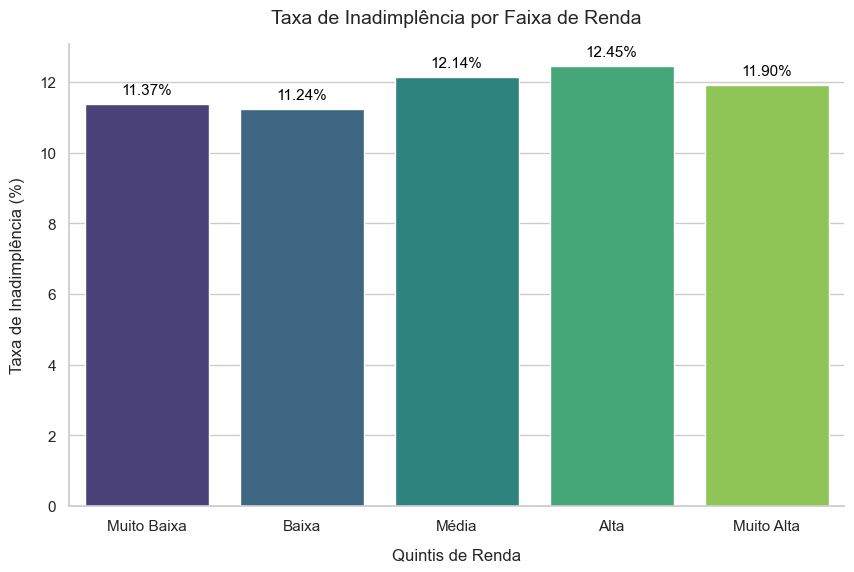

In [44]:
# GRÁFICO DE BARRAS

df_renda_grafico = (
    df_final.groupby('faixa_renda', observed=False)['inadimplente']
    .mean()
    .reset_index()
)

df_renda_grafico['taxa_inadimplencia'] = df_renda_grafico['inadimplente'] * 100

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_renda_grafico,
    x='faixa_renda',
    y='taxa_inadimplencia',
    hue='faixa_renda',       
    palette='viridis',       
    legend=False
)

plt.title('Taxa de Inadimplência por Faixa de Renda', fontsize=14, pad=15)
plt.xlabel('Quintis de Renda', fontsize=12, labelpad=10)
plt.ylabel('Taxa de Inadimplência (%)', fontsize=12, labelpad=10)

for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:.2f}%',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom',
                fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.show()